# 03  ·  Preprocessing

Three steps — bandpass, common-average reference, per-channel z-score.
Every one of them is justified, and the *order* and *scope* matter:

1. **Bandpass 4–40 Hz** — keep the cognitively relevant range, kill DC drift
   and high-frequency muscle artifact.
2. **Common-average reference (CAR)** — subtract the across-channel mean at
   each time point; removes shared noise (line, reference electrode).
3. **Per-channel z-score** — but fit on the *train fold only* and apply to
   the validation fold; otherwise we leak distributional information across
   folds.


In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from eeg_cognitive import make_motor_imagery_synthetic
from eeg_cognitive.preprocess import (
    bandpass, common_average_reference, ChannelStandardizer
)

ds = make_motor_imagery_synthetic(n_subjects=1, trials_per_class=10,
                                  snr_db=-12, seed=0)
print(f"raw X shape: {ds.X.shape}")


raw X shape: (40, 22, 500)


## Step 1 — bandpass

Compare the raw signal to its 4–40 Hz bandpassed version. The DC drift and
slow trends should disappear; the cognitively relevant rhythms should
remain intact.

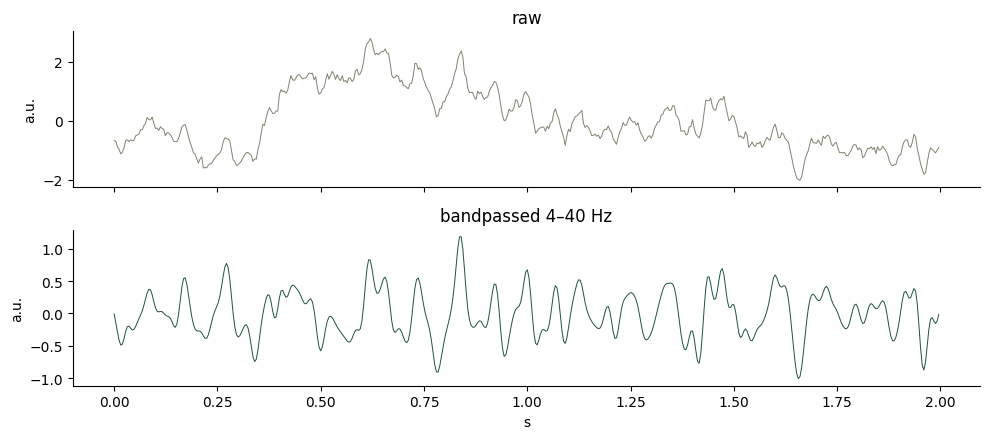

In [3]:
raw = ds.X[0, 0]  # trial 0, channel 0
filt = bandpass(ds.X, ds.sfreq, l_freq=4, h_freq=40)[0, 0]
t = np.arange(len(raw)) / ds.sfreq

fig, ax = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
ax[0].plot(t, raw, color='#82806E', linewidth=0.7)
ax[0].set_title('raw'); ax[0].set_ylabel('a.u.')
ax[1].plot(t, filt, color='#1F4F47', linewidth=0.7)
ax[1].set_title('bandpassed 4–40 Hz'); ax[1].set_xlabel('s'); ax[1].set_ylabel('a.u.')
for a in ax:
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## Step 2 — common-average reference

Subtracting the cross-channel mean removes line-noise–like signals
shared across electrodes. The amplitude per channel typically drops a
little; that's expected.

In [4]:
Xf = bandpass(ds.X, ds.sfreq, 4, 40)
Xc = common_average_reference(Xf)
print(f"std before CAR: {Xf.std():.3f}")
print(f"std after CAR:  {Xc.std():.3f}")


std before CAR: 0.398
std after CAR:  0.274


## Step 3 — leakage-free standardization

The most common subtle bug in EEG ML is fitting `(mean, std)` on the
*whole* dataset before splitting into train/test. That leaks information
from the test fold into the train fold.

Our `ChannelStandardizer` is fit on the train fold only and applied to
the validation fold.

In [5]:
rng = np.random.default_rng(0)
n = len(ds.y)
perm = rng.permutation(n)
tr, te = perm[: int(n*0.8)], perm[int(n*0.8):]

scaler = ChannelStandardizer().fit(Xc[tr])
Xtr = scaler.transform(Xc[tr])
Xte = scaler.transform(Xc[te])

print(f"train mean: {Xtr.mean():.5f}, std: {Xtr.std():.3f}")
print(f"val   mean: {Xte.mean():.5f}, std: {Xte.std():.3f}")
print()
print("note: val mean is NOT exactly 0 — that's the point. The val fold")
print("was standardized using train stats, not its own.")


train mean: 0.00000, std: 1.000
val   mean: -0.00006, std: 1.007

note: val mean is NOT exactly 0 — that's the point. The val fold
was standardized using train stats, not its own.


All three steps are wired into `eeg_cognitive.preprocess.preprocess_epochs`,
which the experiment scripts and the next two notebooks call directly.